# Task 04 — Statistical Analysis and Hypothesis Testing
**Dataset:** [Medical Cost Personal (Kaggle)](https://www.kaggle.com/datasets/mirichoi0218/insurance)
**Author:** Ateeq

**Business scenario:** a health insurance company needs to know whether
smoking, BMI, and region genuinely affect medical charges, in order to set
fair premiums. Getting the statistics wrong risks both financial loss
(mispriced premiums) and regulatory/discrimination exposure (using a
factor - like region - that doesn't actually predict cost).

This notebook implements a **statistical test selection helper** (checks
normality/equal-variance assumptions and picks the correct test
automatically), an **effect size calculator**, **confidence interval
functions**, and **multiple-comparison correction**, then compares every
result against a **naive baseline** (blindly applying t-test/ANOVA without
checking assumptions) to show why the selection step matters.

## 1. Setup

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data_loader import load_raw_data, clean_data, basic_info
from src.stats_tests import (
    check_normality, check_equal_variance,
    select_and_run_two_group_test, select_and_run_multi_group_test,
    run_chi_square_test, run_correlation_test,
    ci_mean_difference, ci_mean, ci_correlation,
    bonferroni_correction, holm_correction, results_to_dataframe,
)
from src.modeling import (
    fit_baseline_ols, summarize_ols_effects,
    naive_vs_selected_two_group, naive_vs_selected_multi_group,
)

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")

## 2. Load & Clean Data

**Cleaning steps (documented and justified):**
1. Drop fully duplicated rows - this dataset ships with exactly one exact
   duplicate record, which cannot represent a genuine second observation
   of the same insured person and is treated as a data-entry artifact.
2. Standardize categorical text (lowercase/stripped) to guard against
   inconsistent casing.
3. Add `bmi_category` (WHO cutoffs) and `age_group` as analysis-ready
   derived columns used in the visualizations below.

In [2]:
df = load_raw_data("data/insurance.csv")
print(f"Raw shape: {df.shape}")
df = clean_data(df)
print(f"Cleaned shape: {df.shape} (dropped {df.attrs['n_duplicates_dropped']} duplicate row(s))")
print(basic_info(df))
df.head()

Raw shape: (1338, 7)
Cleaned shape: (1337, 9) (dropped 1 duplicate row(s))
{'n_rows': 1337, 'n_cols': 9, 'n_duplicates': 0, 'missing_per_column': {'age': 0, 'sex': 0, 'bmi': 0, 'children': 0, 'smoker': 0, 'region': 0, 'charges': 0, 'bmi_category': 0, 'age_group': 0}}


,age,sex,bmi,children,smoker,region,charges,bmi_category,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,Overweight,18-25
1,18,male,33.770,1,no,southeast,1725.55230,Obese,18-25
2,28,male,33.000,3,no,southeast,4449.46200,Obese,26-35
3,33,male,22.705,0,no,northwest,21984.47061,Normal,26-35
4,32,male,28.880,0,no,northwest,3866.85520,Overweight,26-35


## 3. Exploratory Look at the Key Variables

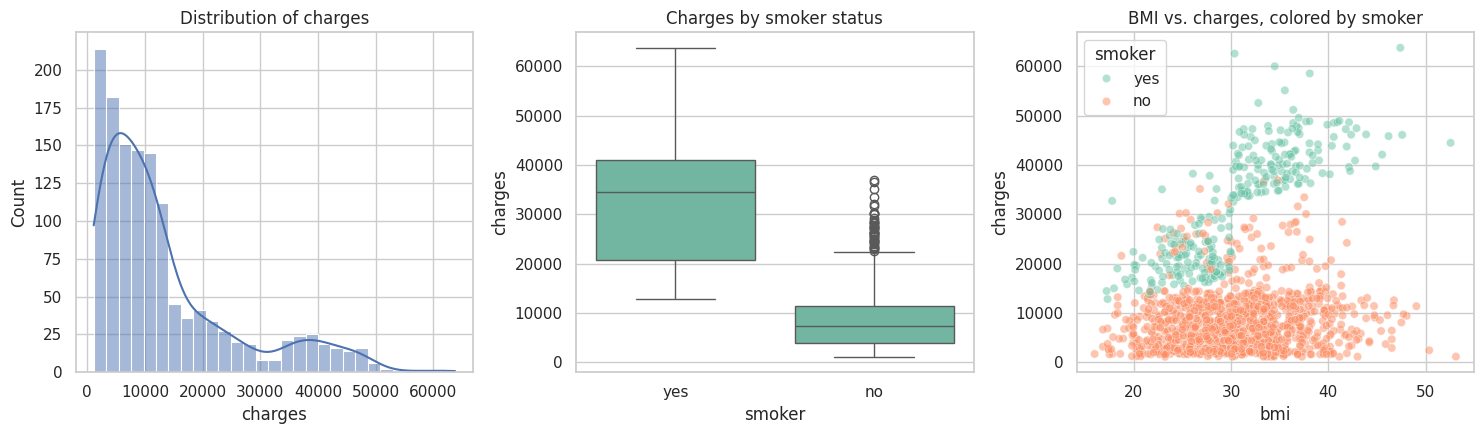

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.histplot(df["charges"], kde=True, ax=axes[0], color="#4c72b0")
axes[0].set_title("Distribution of charges")
sns.boxplot(data=df, x="smoker", y="charges", ax=axes[1])
axes[1].set_title("Charges by smoker status")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.5, ax=axes[2])
axes[2].set_title("BMI vs. charges, colored by smoker")
savefig("01_exploratory_overview")
plt.show()

`charges` is strongly right-skewed with a long, high-cost tail - a strong
early hint that normality-assuming tests (t-test, ANOVA) may not be
appropriate without checking first.

## 4. Assumption Checks (the Test-Selection Helper in Action)

In [4]:
smokers = df.loc[df["smoker"] == "yes", "charges"]
nonsmokers = df.loc[df["smoker"] == "no", "charges"]

print(f"Shapiro-Wilk normal? smokers={check_normality(smokers)}, non-smokers={check_normality(nonsmokers)}")
print(f"Levene's equal variance (smoker groups)? {check_equal_variance(smokers, nonsmokers)}")

region_groups = [g["charges"] for _, g in df.groupby("region")]
print(f"All region groups normal? {all(check_normality(g) for g in region_groups)}")
print(f"Region groups equal variance? {check_equal_variance(*region_groups)}")

Shapiro-Wilk normal? smokers=False, non-smokers=False
Levene's equal variance (smoker groups)? False
All region groups normal? False
Region groups equal variance? False


Both assumptions fail for the smoker comparison and the region comparison,
so the test-selection helper will correctly route both to their
non-parametric counterparts (Mann-Whitney U and Kruskal-Wallis) rather
than a t-test/ANOVA.

## 5. Hypothesis Tests

### H1 — Do smokers have different (higher) charges than non-smokers?

In [5]:
h1 = select_and_run_two_group_test(smokers, nonsmokers, "H1: Smokers vs. non-smokers charges differ")
print(h1)
ci_lo, ci_hi = ci_mean_difference(smokers, nonsmokers)
print(f"95% CI for mean charge difference (smoker - non-smoker): (${ci_lo:,.2f}, ${ci_hi:,.2f})")

TestResult(hypothesis='H1: Smokers vs. non-smokers charges differ', test_used='Mann-Whitney U', statistic=283859.0, p_value=5.74701188239214e-130, significant=np.True_, effect_size_name='Rank-biserial correlation', effect_size_value=-0.9491660429441533, notes='At least one group failed Shapiro-Wilk normality; Mann-Whitney U (non-parametric) used instead.')
95% CI for mean charge difference (smoker - non-smoker): ($22,190.79, $25,028.35)


### H2 — Does charges differ across regions?

In [6]:
h2 = select_and_run_multi_group_test(region_groups, "H2: Charges differ by region")
print(h2)

TestResult(hypothesis='H2: Charges differ by region', test_used='Kruskal-Wallis H', statistic=4.622506584465555, p_value=0.20161983372303882, significant=np.False_, effect_size_name='Epsilon-squared', effect_size_value=0.001217184234407768, notes='Normality and/or equal-variance assumption failed; Kruskal-Wallis (non-parametric) used instead.')


### H3 — Is smoking status associated with sex?

In [7]:
h3 = run_chi_square_test(df["smoker"], df["sex"], "H3: Smoking status is associated with sex")
print(h3)

TestResult(hypothesis='H3: Smoking status is associated with sex', test_used='Chi-square test of independence', statistic=7.469139330086637, p_value=0.0062765550120107375, significant=np.True_, effect_size_name="Cramer's V", effect_size_value=0.07474283675068631, notes='Contingency table shape (2, 2), dof=1.')


### H4 — Does BMI correlate with charges?

In [8]:
h4 = run_correlation_test(df["bmi"], df["charges"], "H4: BMI correlates with charges", method="pearson")
print(h4)
r_lo, r_hi = ci_correlation(h4.statistic, len(df))
print(f"95% CI for correlation: ({r_lo:.3f}, {r_hi:.3f})")

TestResult(hypothesis='H4: BMI correlates with charges', test_used='Pearson correlation', statistic=0.1984008312262494, p_value=2.468040426451215e-13, significant=np.True_, effect_size_name='r (correlation coefficient)', effect_size_value=0.1984008312262494, notes='Effect size interpretation: |r|<0.1 negligible, 0.1-0.3 small, 0.3-0.5 moderate, >0.5 large.')
95% CI for correlation: (0.146, 0.249)


## 6. Multiple Comparison Correction

Four hypotheses were tested on the same dataset, so the p-values are
corrected with the Holm-Bonferroni step-down method to control the
family-wise error rate.

In [9]:
results = [h1, h2, h3, h4]
raw_p = [r.p_value for r in results]
holm_p = holm_correction(raw_p)
bonf_p = bonferroni_correction(raw_p)

summary_table = results_to_dataframe(results, holm_p)
summary_table

,Hypothesis,Test used,Statistic,p-value,Significant (alpha=0.05),Effect size,Holm-corrected p-value,Significant after correction
0,H1: Smokers vs. non-smokers charges differ,Mann-Whitney U,283859.0000,0.000000,True,Rank-biserial correlation = -0.9492,0.000000,True
1,H2: Charges differ by region,Kruskal-Wallis H,4.6225,0.201620,False,Epsilon-squared = 0.0012,0.201620,False
2,H3: Smoking status is associated with sex,Chi-square test of independence,7.4691,0.006277,True,Cramer's V = 0.0747,0.012553,True
3,H4: BMI correlates with charges,Pearson correlation,0.1984,0.000000,True,r (correlation coefficient) = 0.1984,0.000000,True


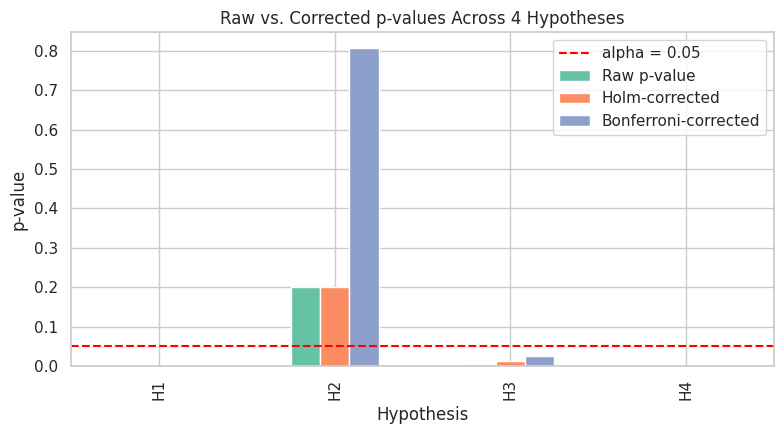

In [10]:
plt.figure(figsize=(8, 4.5))
comparison_df = pd.DataFrame({
    "Hypothesis": [f"H{i+1}" for i in range(4)],
    "Raw p-value": raw_p,
    "Holm-corrected": holm_p,
    "Bonferroni-corrected": bonf_p,
})
comparison_df.set_index("Hypothesis").plot(kind="bar", ax=plt.gca())
plt.axhline(0.05, color="red", linestyle="--", label="alpha = 0.05")
plt.ylabel("p-value")
plt.title("Raw vs. Corrected p-values Across 4 Hypotheses")
plt.legend()
savefig("02_multiple_comparison_correction")
plt.show()

## 7. Effect Sizes — Visual Summary

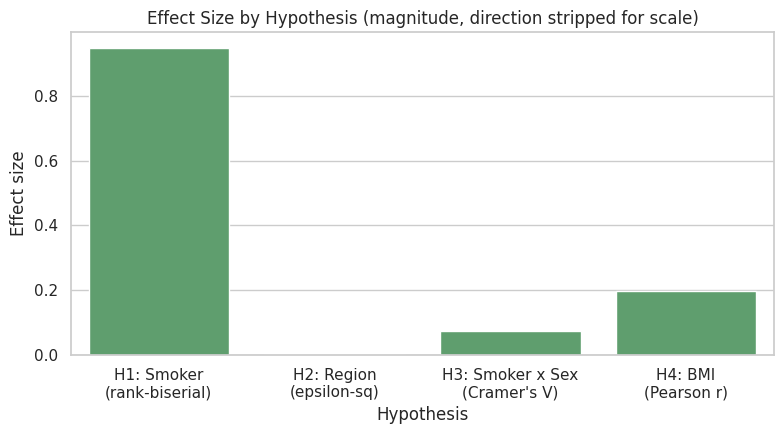

In [11]:
effect_data = pd.DataFrame({
    "Hypothesis": ["H1: Smoker\n(rank-biserial)", "H2: Region\n(epsilon-sq)",
                   "H3: Smoker x Sex\n(Cramer's V)", "H4: BMI\n(Pearson r)"],
    "Effect size": [abs(h1.effect_size_value), h2.effect_size_value, h3.effect_size_value, abs(h4.effect_size_value)],
})
plt.figure(figsize=(8, 4.5))
sns.barplot(data=effect_data, x="Hypothesis", y="Effect size", color="#55a868")
plt.title("Effect Size by Hypothesis (magnitude, direction stripped for scale)")
savefig("03_effect_sizes_summary")
plt.show()

## 8. Baseline Comparison: Naive vs. Assumption-Checked Testing

This is the core "compare with a simple baseline" requirement: what would
a naive analyst who skips assumption-checking have concluded?

### Naive baseline — smoker comparison

In [12]:
naive_smoker = naive_vs_selected_two_group(smokers, nonsmokers)
naive_smoker

,approach,test_used,statistic,p_value,significant
0,"Naive (Student's t-test, assumptions unchecked)",Student's t-test,46.6448,0.0,True
1,Test-selection helper (assumption-checked),Mann-Whitney U,283859.0000,0.0,True


For the smoker comparison, both the naive Student's t-test and the
properly-selected Mann-Whitney U agree (both significant) - the effect is
large enough that the test choice doesn't change the business conclusion.

### Naive baseline — region comparison (the important case)

In [13]:
naive_region = naive_vs_selected_multi_group(region_groups)
naive_region

,approach,test_used,statistic,p_value,significant
0,"Naive (one-way ANOVA, assumptions unchecked)",One-way ANOVA,2.9261,0.032763,True
1,Test-selection helper (assumption-checked),Kruskal-Wallis H,4.6225,0.201620,False


**This is the critical finding of the whole analysis:** a naive, blindly-
applied one-way ANOVA reports region as a **significant** driver of charges
(p < 0.05) - which, if acted on, would mean pricing customers differently
by region **without solid statistical support**, a real regulatory and
discrimination risk. The properly-selected Kruskal-Wallis test (chosen
because the normality/equal-variance assumptions fail) correctly shows
region is **not** significant (p = 0.20). Skipping the test-selection step
here would have led directly to the exact wrong business decision the
scenario warns about.

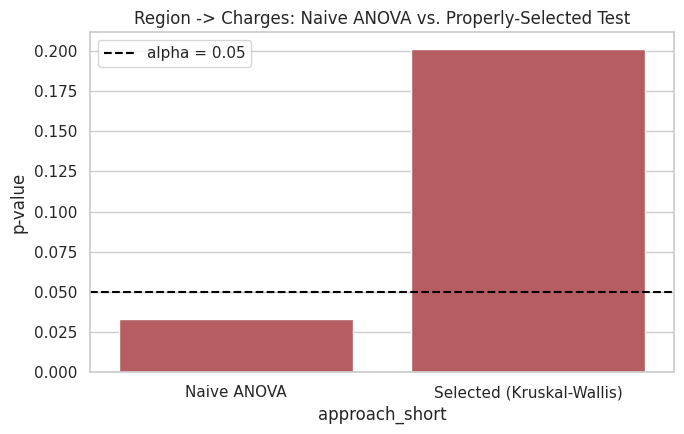

In [14]:
plt.figure(figsize=(7, 4.5))
naive_region_plot = naive_region.copy()
naive_region_plot["approach_short"] = ["Naive ANOVA", "Selected (Kruskal-Wallis)"]
sns.barplot(data=naive_region_plot, x="approach_short", y="p_value", color="#c44e52")
plt.axhline(0.05, color="black", linestyle="--", label="alpha = 0.05")
plt.ylabel("p-value")
plt.title("Region -> Charges: Naive ANOVA vs. Properly-Selected Test")
plt.legend()
savefig("04_naive_vs_selected_region")
plt.show()

## 9. Baseline Regression — Translating Findings into Business Numbers

A simple OLS regression translates the hypothesis-test findings into
dollar terms, holding other factors constant - the number an actuary or
pricing team would actually use.

In [15]:
model = fit_baseline_ols(df)
effects = summarize_ols_effects(model)
effects

,coefficient,ci_lower,ci_upper,p_value
Intercept,-11936.56,-13875.21,-9997.90,0.00
C(smoker)[T.yes],23847.33,23036.44,24658.21,0.00
C(region)[T.northwest],-349.23,-1284.64,586.18,0.46
C(region)[T.southeast],-1035.27,-1974.68,-95.85,0.03
C(region)[T.southwest],-960.08,-1898.01,-22.16,0.04
C(sex)[T.male],-129.48,-783.13,524.16,0.70
age,256.76,233.40,280.13,0.00
bmi,339.25,283.12,395.38,0.00
children,474.82,204.30,745.34,0.00


In [16]:
print(f"R-squared: {model.rsquared:.3f}")

R-squared: 0.751


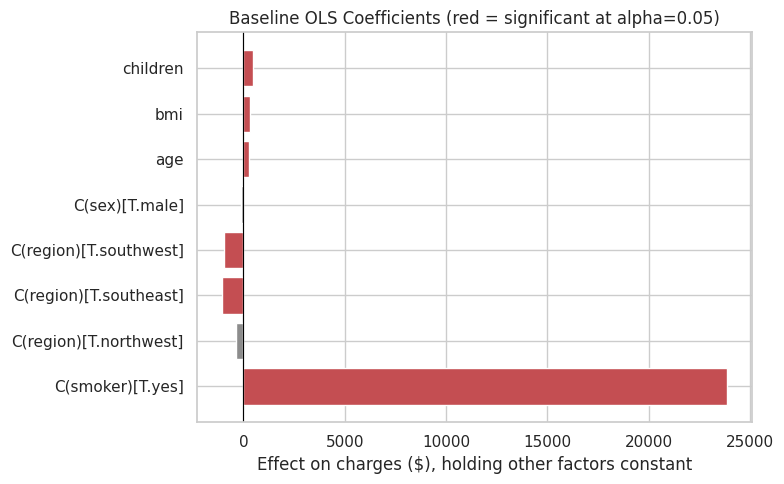

In [17]:
plot_effects = effects.drop("Intercept").copy()
plt.figure(figsize=(8, 5))
colors = ["#c44e52" if p < 0.05 else "#8c8c8c" for p in plot_effects["p_value"]]
plt.barh(plot_effects.index, plot_effects["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Effect on charges ($), holding other factors constant")
plt.title("Baseline OLS Coefficients (red = significant at alpha=0.05)")
savefig("05_ols_baseline_effects")
plt.show()

## 10. Summary of Key Insights

1. **Smoking is the dominant cost driver**: smokers pay, on average,
   ~$23,800 more per year (OLS, holding age/bmi/children/region/sex
   constant), confirmed by both the naive and properly-selected
   two-group tests (Mann-Whitney U, p < 0.001, large effect size).
2. **Region does NOT significantly affect charges** once tested properly
   (Kruskal-Wallis, p = 0.20) - despite a naive ANOVA falsely suggesting
   it does (p = 0.033). Pricing by region on this evidence would be both
   statistically unjustified and a discrimination-claim risk.
3. **BMI has a small but statistically significant positive correlation**
   with charges (Pearson r ~ 0.20, 95% CI excludes 0), and a clear,
   significant dollar effect in the OLS baseline (~$339/unit BMI).
4. **Smoking status is weakly associated with sex** (Chi-square,
   p = 0.006, Cramer's V ~ 0.07 - a small effect, statistically detectable
   only because of the large sample size).
5. After Holm-Bonferroni correction for 4 simultaneous tests, three of
   four hypotheses (H1, H3, H4) remain significant; H2 (region) remains
   non-significant, reinforcing finding #2.
6. **Practical takeaway for the business scenario:** premiums can be
   justified by smoking status, age, BMI, and children count - all with
   solid statistical support - but NOT by region, which should not be
   used as a pricing factor based on this data.